In [1]:
import sys
import os

sys.path.append(os.path.abspath('./predictability_emergence')) 

import DataMakar
import DataHolder
import buildmodel
import helpers

import importlib as imp
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim

import torch.optim.lr_scheduler as lr_scheduler
import time

import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

import glob
import json
import pickle
from scipy.stats import percentileofscore
from statsmodels.stats.contingency_tables import mcnemar

from PIL import Image

import cartopy.crs as ccrs
import matplotlib as mpl
from matplotlib.colors import BoundaryNorm
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

mpl.rcParams['figure.facecolor'] = 'white'
mpl.rcParams['figure.dpi'] = 150
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.size'] = 12
mpl.rcParams['font.sans-serif']=['Verdana']

params = {"ytick.color": "k",
          "xtick.color": "k",
          "axes.labelcolor": "k",
          "axes.edgecolor": "k"}
plt.rcParams.update(params)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import joblib

ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/Users/egor650/.local/share/mamba/envs/ml-env/lib/python3.9/site-packages/traitlets/traitlets.py", line 632, in get
    value = obj._trait_values[self.name]
KeyError: '_control_lock'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/Users/egor650/.local/share/mamba/envs/ml-env/lib/python3.9/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
  File "/Users/egor650/.local/share/mamba/envs/ml-env/lib/python3.9/site-packages/ipykernel/kernelbase.py", line 301, in dispatch_control
    async with self._control_lock:
  File "/Users/egor650/.local/share/mamba/envs/ml-env/lib/python3.9/site-packages/traitlets/traitlets.py", line 687, in __get__
    return t.cast(G, self.get(obj, cls))  # the G should encode the Optional
  File "/Users/egor650/.local/share/mamba/envs/ml-env/lib/python3.9/site-packa

In [27]:
ssplist = ["370"]

ssplistplot = ["hist","370"] # thank god i haven't flipflopped on ssp labeling! that would be so annoying

# set user parameters

experiment_era = [1970,2100]
baselineera = [1900,1950]
trainvaltest = [np.arange(25),np.arange(25,38),np.arange(38,50)]

experiment_era_obs = [1970,2025]
baselineera_obs = [1950,1980]

inputlength = 10
outputavgtime = 5
# data params
outres = 10
timerange = [1900,2100]
filefront = "MPI_"
modelfilefront = "MPI_recordtemp_"
annmodelfilefront = "MPI_recordtemp_nosst"
inres = 4
inputvar = 'tos'
outputvar = 'tas'
obstimerange = [1940,2025]
data_dir = 'data'

seedlist = [62469869,
            71856281,
            47621498,
            10431957,
            50561320,
            72166634,
            18469465,
            92895735,
            57693846,
            22284750]

imp.reload(DataHolder)

params = {
    "outres": outres,
    "timerange": timerange,
    "filefront": filefront,
    "inres": inres,
    "inputvar":inputvar,
    "outputvar":outputvar,
    "seedlist": seedlist,
    "obstimerange":obstimerange,
    "data_dir":data_dir
}

ntrain = 25
nval = 13
test = np.arange(38,50)

n_best = 3

#get the data

AllData = DataHolder.MPIInputOutput_SSPlist(params,ssplist)

latvec = AllData.output_lat
lonvec = AllData.output_lon

lonmesh,latmesh = np.meshgrid(lonvec+5,latvec+5)

device = 'mps'


data/MPI_annualmean_370_tos_1900-2100.pkl


In [3]:

imp.reload(DataHolder)
AllObs = DataHolder.ERA5InputOutput(params)

lenobs = experiment_era_obs[1]-experiment_era_obs[0]-outputavgtime-inputlength+1

In [4]:
landmask = np.isnan(np.nanmean(AllObs.alloutput,axis=0))

In [5]:
latsel = 40
lonsel = 0

metricsout = "metrics/"+modelfilefront+"avgtime_"+str(outputavgtime)+"_allssps_lat_"+str(latsel)+"_lon_"+str(lonsel)+"_seed*.json"
filelist = glob.glob(metricsout)

bestseeds = helpers.get_best_files(filelist,n_best)
# obsinput,obsinputgmt,obsinputpriorrecord,obsoutput = AllObs.obs_histrecordmax_nochopend(experiment_era_obs,baselineera_obs,inputlength,outputavgtime,latsel,lonsel)
obsinput,obsinputgmt,obsinputpriorrecord,obsoutput = AllObs.obs_recordmax_withrecordmax_nochopend(experiment_era_obs,baselineera_obs,inputlength,outputavgtime,latsel,lonsel)

obsinput_t = torch.tensor(obsinput,dtype=torch.float32)
obsinputgmt_t = torch.tensor(obsinputgmt,dtype=torch.float32)
obsinputpriorrecord_t = torch.tensor(obsinputpriorrecord,dtype=torch.float32)
obsinputvectors_t = torch.cat((obsinputgmt_t,obsinputpriorrecord_t),axis=-1)

obsinput_climo_t = torch.ones(obsinput_t.size())*torch.mean(obsinput_t,axis=0,keepdims=True)

obspredall = np.empty((3,len(obsinputgmt)))

_, _, alltest = AllData.trainvaltest_histrecordmax(trainvaltest,experiment_era,baselineera,inputlength,outputavgtime,latsel,lonsel)

MPIinputtest, MPIinputtestGMT, MPIoutputtest = DataHolder.tensortime_onehot_withrecordmax(alltest,nclasses=2)

MPIpredall = np.empty((3,MPIinputtest.shape[0]))

obspredclimo = np.empty((3,len(obsinputgmt)))

for iseed,seed in enumerate(bestseeds):
    # load the model

    loadfile = "models/"+modelfilefront+"avgtime_"+str(outputavgtime)+"_allssps_lat_"+str(latsel)+"_lon_"+str(lonsel)+"_seed_"+str(seed)+".pt"
    cnn = buildmodel.CNNclassifier(obsinput_t, obsinputvectors_t, 2).to('cpu')
    cnn.load_state_dict(torch.load(loadfile,map_location=torch.device('cpu'), weights_only=False))
    cnn.to(device)

    with torch.no_grad():
        cnn.eval()
        MPIpred = cnn(MPIinputtest.to(device), MPIinputtestGMT.to(device)).cpu().numpy()

    MPIpredall[iseed,] = MPIpred[:,1]


obspredavg = np.mean(obspredall,axis=0)
obspredclass = np.round(obspredavg)
MPIpredavg = np.mean(MPIpredall,axis=0)
climopredavg = np.mean(obspredclimo,axis=0)


baseline for temp records is 0 50 (not used)
indices of future period are 104 -4
working on 370


/Users/egor650/Documents/Experiments/predictability-emergence/predictability_emergence/DataHolder.py:2138: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  outputdata_t = torch.tensor(outputonehotencoded,dtype=torch.float32)


In [6]:
def expectedcalibrationerror(pred,true,interval):

    confints = np.arange(0,1,interval)

    calibcurve = np.empty(len(confints))
    nsamps = np.empty(len(confints))

    for isel,ii in enumerate(confints):

        MPIsel = (pred>ii) & (pred<(ii+interval))
        calibcurve[isel] = np.mean(true[MPIsel])

        nsamps[isel] = len(true[MPIsel])

    ece = np.sum(nsamps*np.abs(calibcurve-confints))/len(pred)

    return ece,calibcurve


In [44]:
filepredictions = "predictions/"+modelfilefront+"avgtime_"+str(outputavgtime)+"_allssps_allseeds_lat_70_testing.pkl"
with open(filepredictions,'rb') as f:
    predictions = pickle.load(f)

array([[       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [0.49447566, 0.61172153, 0.66054293, ..., 0.35272277, 0.35652653,
        0.03840103],
       [0.43459998, 0.56260728, 0.59905077, ..., 0.4374213 , 0.50241013,
        0.02765051],
       ...,
       [0.11561023, 0.17105623, 0.22374636, ..., 0.9605392 , 0.97549954,
        0.98306511],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan]])

In [52]:
ece = np.empty((18,36))
ece_ann = np.empty((18,36))

for ilatsel,latsel in enumerate(np.arange(-90,90,10)):

    filepredictions = "predictions/"+modelfilefront+"avgtime_"+str(outputavgtime)+"_allssps_allseeds_lat_"+str(latsel)+"_testing.pkl"
    annfilepredictions = "predictions/"+annmodelfilefront+"avgtime_"+str(outputavgtime)+"_allssps_allseeds_lat_"+str(latsel)+"_testing.pkl"
    filecheck = glob.glob(filepredictions)

    if len(filecheck)>0:

        with open(filepredictions,'rb') as f:
            predictions = pickle.load(f)

        with open(annfilepredictions,'rb') as f:
            annpredictions = pickle.load(f)

        filetrue = "predictions/"+modelfilefront+"avgtime_"+str(outputavgtime)+"_allssps_allseeds_lat_"+str(latsel)+"_truetesting.pkl"

        with open(filetrue,'rb') as f:
            truths = pickle.load(f)

        meanpred = np.mean(predictions[:,:9],axis=1)
        annmeanpred = np.mean(annpredictions[:,:9],axis=1)

        for ilon in np.arange(36):
            ece[ilatsel,ilon],_ = expectedcalibrationerror(meanpred[ilon],truths[ilon],0.1)
            ece_ann[ilatsel,ilon],_ = expectedcalibrationerror(annmeanpred[ilon],truths[ilon],0.1)

ece[:2,:] = np.nan
ece_ann[:2,:] = np.nan



In [53]:
annmeanpred.shape

(36, 4092)

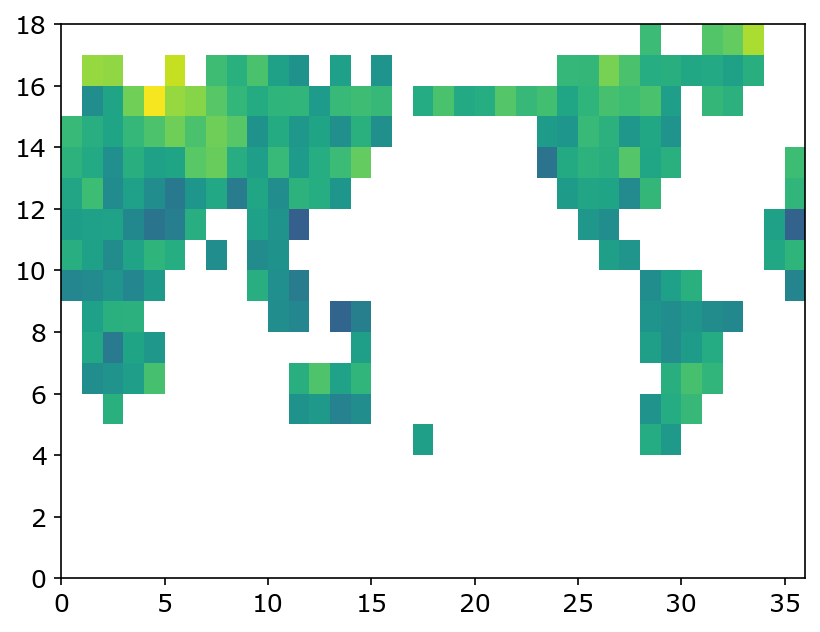

In [54]:
plt.pcolormesh(ece,vmin=0,vmax=0.2)

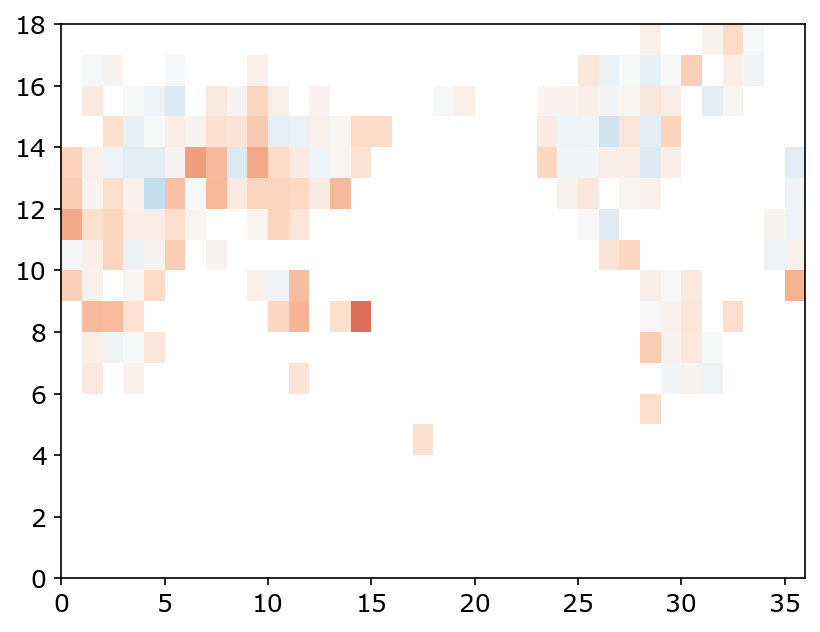

In [51]:
plt.pcolormesh(ece_ann-ece,vmin=-0.1,vmax=0.1,cmap='RdBu_r')

In [ ]:
ecesel,calibcurve = expectedcalibrationerror(meanpred[0],truths[0],0.1)

In [ ]:
ece

array([0.13084936, 0.13261218, 0.11650641, 0.1193109 , 0.16522436,
       0.11546474, 0.21129808, 0.14951923, 0.15200321, 0.13197115,
       0.06810897, 0.1088141 , 0.10929487, 0.12123397, 0.15216346,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan, 0.109375  , 0.09310897,
       0.14423077, 0.1443109 , 0.16346154, 0.12636218, 0.12700321,
              nan,        nan,        nan,        nan,        nan,
       0.14815705])

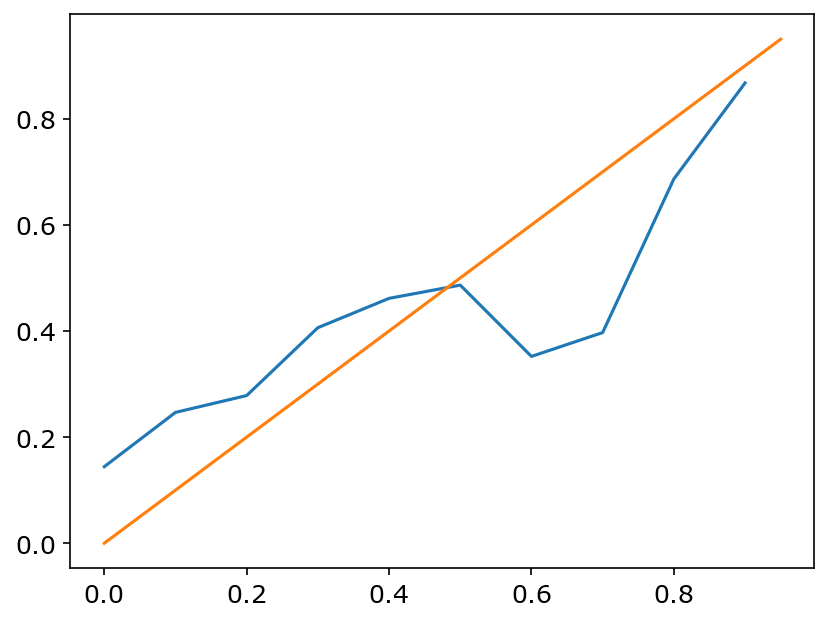

In [ ]:
plt.plot(np.arange(0,1,0.1),calibcurve)
plt.plot(np.arange(0,1,0.05),np.arange(0,1,0.05))